# 02 – EDA: Weighted Graph Analysis

**Global Cargo Shipping Network (GCSN) — 2015 vs 2025**

Methodology follows **Kaluza et al. (2010)**, *J. R. Soc. Interface*, Figure 2b–d and Table 1.

Edge **weight w(u,v)** = number of ship voyages from port u to port v in the year.

### Analyses performed
1. Build directed + undirected weighted graphs
2. Edge weight distribution P(w) — Fig. 2b analog
3. Node strength distribution P(s) — Fig. 2c analog
4. Strength–degree scaling s(k) ~ k^alpha — Fig. 2d analog (superlinear?)
5. Weighted clustering coefficient
6. Weighted assortativity
7. Top ports by strength (traffic load)
8. Route (edge) analysis — most heavily used routes
9. Summary table — 2015 vs 2025 vs Paper 2007 baseline
10. **Kaluza Table 1 full replication** — structural metrics: 2015 & 2025 vs all paper cargo-type baselines
11. **Kaluza Fig. 2 composite** — P(w), P(s), s(k) for both years in paper figure style


In [13]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import stats

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
})

FIG_DIR = '../Figures/'
os.makedirs(FIG_DIR, exist_ok=True)

# Paper (Kaluza et al. 2010) baseline — full GCSN, 2007
PAPER_2007 = {
    'nodes': 951,
    'mean_degree': 44.61,
    'journeys_per_link': 10.4,
    'weight_exponent_mu': 1.42,   # link weight P(w) ~ w^{-mu}
    'strength_exponent_eta': 1.02, # strength P(s) ~ s^{-eta}
    'superlinear_alpha': 1.36,     # s(k) ~ k^alpha
    'clustering': 0.49,
}

print('Imports OK. NetworkX', nx.__version__)
print('Figures will be saved to:', os.path.abspath(FIG_DIR))


Imports OK. NetworkX 3.4.2
Figures will be saved to: c:\Git\NS_Project\GCSN-Analysis\Figures


## 1. Load Edge Lists and Build Weighted Graphs


In [14]:
DATA_2015 = '../EdgeList/shipping_network_2015.csv'
DATA_2025 = '../EdgeList/shipping_network_2025.csv'

df_2015 = pd.read_csv(DATA_2015)
df_2025 = pd.read_csv(DATA_2025)


def build_weighted_graphs(df):
    """
    Build directed and undirected weighted graphs.
    Undirected weight: sum of both directions  w_u(u,v) = w(u,v) + w(v,u).
    """
    # Directed weighted
    Gd = nx.from_pandas_edgelist(
        df, 'source', 'target', edge_attr='weight',
        create_using=nx.DiGraph())

    # Undirected weighted (merge both directions)
    Gu = nx.Graph()
    for _, row in df.iterrows():
        u, v, w = row['source'], row['target'], row['weight']
        if Gu.has_edge(u, v):
            Gu[u][v]['weight'] += w
        else:
            Gu.add_edge(u, v, weight=w)

    return Gd, Gu


Gd_2015, Gu_2015 = build_weighted_graphs(df_2015)
Gd_2025, Gu_2025 = build_weighted_graphs(df_2025)


def weighted_summary(Gd, Gu, year):
    weights_d = np.array([d['weight'] for _, _, d in Gd.edges(data=True)])
    weights_u = np.array([d['weight'] for _, _, d in Gu.edges(data=True)])
    strengths = np.array([d for _, d in Gu.degree(weight='weight')])

    print(f'\n{"="*54}')
    print(f'  {year} Weighted Network')
    print(f'{"="*54}')
    print(f'  Directed edges          : {Gd.number_of_edges():>9,}')
    print(f'  Undirected edges        : {Gu.number_of_edges():>9,}')
    print(f'  Total voyages (sum w)   : {weights_d.sum():>9,}')
    print(f'  Mean link weight <J>    : {weights_d.mean():>9.2f}')
    print(f'  Median link weight      : {np.median(weights_d):>9.2f}')
    print(f'  Max link weight         : {weights_d.max():>9,}')
    print(f'  Mean node strength <s>  : {strengths.mean():>9.2f}')
    print(f'  Max node strength       : {strengths.max():>9,}')

    return {
        'weights_d': weights_d, 'weights_u': weights_u,
        'strengths': strengths,
        'mean_J': float(weights_d.mean()),
        'mean_s': float(strengths.mean()),
        'max_w': int(weights_d.max()),
    }


ws_2015 = weighted_summary(Gd_2015, Gu_2015, '2015')
ws_2025 = weighted_summary(Gd_2025, Gu_2025, '2025')



  2015 Weighted Network
  Directed edges          :   188,545
  Undirected edges        :   145,745
  Total voyages (sum w)   : 1,791,795
  Mean link weight <J>    :      9.50
  Median link weight      :      1.00
  Max link weight         :    10,269
  Mean node strength <s>  :    504.94
  Max node strength       :   129,906

  2025 Weighted Network
  Directed edges          :   182,300
  Undirected edges        :   139,499
  Total voyages (sum w)   : 1,965,325
  Mean link weight <J>    :     10.78
  Median link weight      :      2.00
  Max link weight         :    12,779
  Mean node strength <s>  :    509.35
  Max node strength       :   132,175


## 2. Link Weight Distribution P(w)

Kaluza et al. Fig. 2b: P(w) ~ w^{-mu} with mu ≈ 1.42 (container ships) to 1.73 (oil tankers).

A heavy-tailed weight distribution means a few routes dominate most of the traffic.


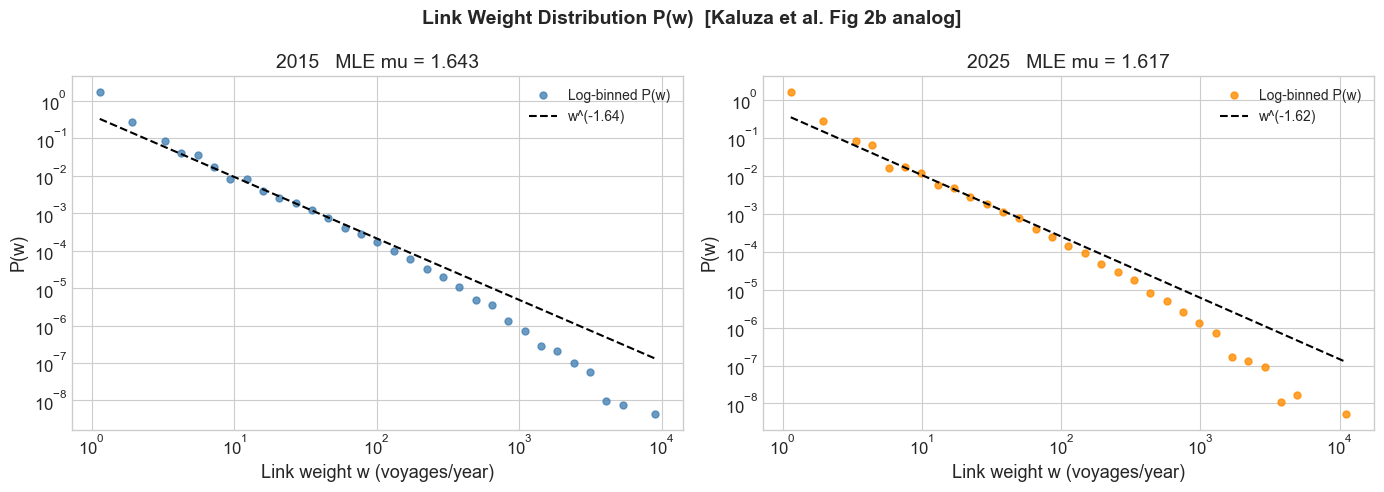


Paper 2007 weight exponent mu: ~1.42 (container) to ~1.73 (oil tankers)
2015 mu = 1.643,   2025 mu = 1.617


In [15]:
def log_binning(data, n_bins=35):
    """Log-spaced histogram, geometric-mean centres, density normalised."""
    data = np.asarray(data, dtype=float)
    data = data[data > 0]
    if len(data) < 2:
        return np.array([]), np.array([])
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), n_bins + 1)
    hist, edges = np.histogram(data, bins=bins, density=True)
    centres = np.sqrt(edges[:-1] * edges[1:])
    mask = hist > 0
    return centres[mask], hist[mask]


def mle_powerlaw(data, x_min=None):
    """MLE power-law exponent (continuous approximation)."""
    data = np.asarray(data, dtype=float)
    if x_min is None:
        x_min = data.min()
    data = data[data >= x_min]
    n = len(data)
    if n == 0:
        return np.nan
    return 1.0 + n / np.sum(np.log(data / (x_min - 0.5)))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Link Weight Distribution P(w)  [Kaluza et al. Fig 2b analog]',
             fontsize=14, fontweight='bold')

mu_w = {}

for ax, (year, ws, color) in zip(axes, [
    ('2015', ws_2015, 'steelblue'),
    ('2025', ws_2025, 'darkorange')
]):
    w = ws['weights_d']
    xw, pw = log_binning(w)
    mu = mle_powerlaw(w, x_min=1)
    mu_w[year] = mu

    ax.loglog(xw, pw, 'o', ms=5, alpha=0.8, color=color, label='Log-binned P(w)')

    # Fitted power-law reference line
    if len(xw) > 1:
        mid = len(xw) // 3
        scale = pw[mid] * xw[mid] ** mu
        x_fit = np.logspace(np.log10(xw.min()), np.log10(xw.max()), 200)
        ax.loglog(x_fit, scale * x_fit**(-mu), 'k--', lw=1.5,
                  label=f'w^(-{mu:.2f})')

    ax.set_xlabel('Link weight w (voyages/year)')
    ax.set_ylabel('P(w)')
    ax.set_title(f'{year}   MLE mu = {mu:.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR + '02_weight_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nPaper 2007 weight exponent mu: ~1.42 (container) to ~1.73 (oil tankers)')
print(f'2015 mu = {mu_w["2015"]:.3f},   2025 mu = {mu_w["2025"]:.3f}')


## 3. Node Strength Distribution P(s)

Node strength: s_i = sum of all edge weights incident to node i.

Kaluza et al. Fig. 2c: P(s) ~ s^{-eta}, eta ≈ 1.02–1.05 across ship types.

Node strength captures the **total traffic load** on a port.


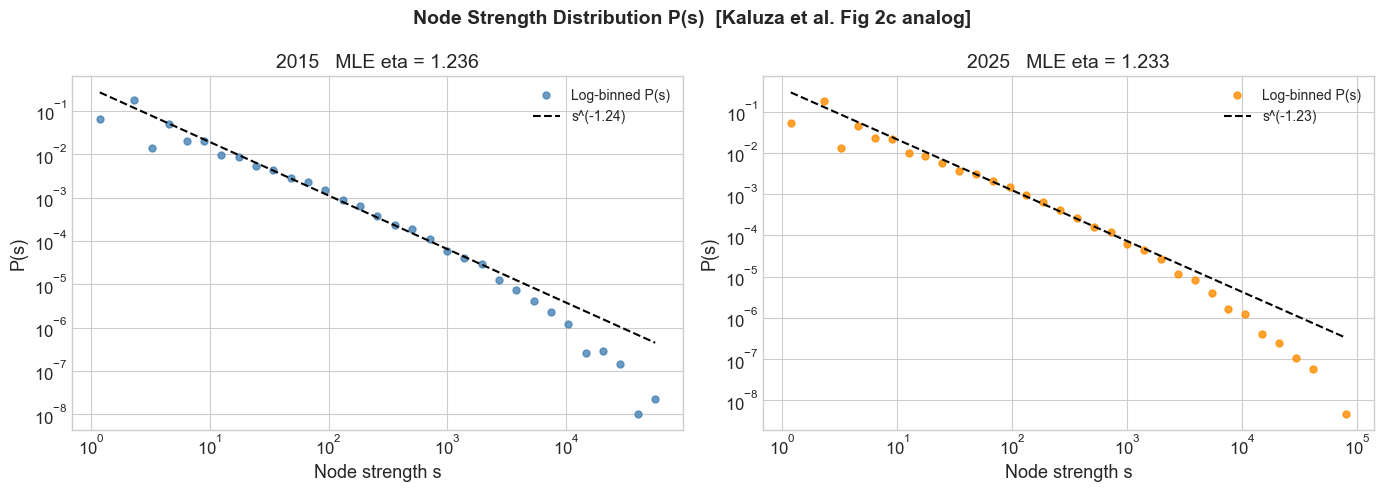

Paper 2007 strength exponent eta ~ 1.02–1.05
2015 eta = 1.236,   2025 eta = 1.233


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Node Strength Distribution P(s)  [Kaluza et al. Fig 2c analog]',
             fontsize=14, fontweight='bold')

eta_s = {}

for ax, (year, ws, Gu, color) in zip(axes, [
    ('2015', ws_2015, Gu_2015, 'steelblue'),
    ('2025', ws_2025, Gu_2025, 'darkorange')
]):
    s = ws['strengths']
    xs, ps = log_binning(s)
    eta = mle_powerlaw(s, x_min=1)
    eta_s[year] = eta

    ax.loglog(xs, ps, 'o', ms=5, alpha=0.8, color=color, label='Log-binned P(s)')

    if len(xs) > 1:
        mid = len(xs) // 3
        scale = ps[mid] * xs[mid] ** eta
        x_fit = np.logspace(np.log10(xs.min()), np.log10(xs.max()), 200)
        ax.loglog(x_fit, scale * x_fit**(-eta), 'k--', lw=1.5,
                  label=f's^(-{eta:.2f})')

    ax.set_xlabel('Node strength s')
    ax.set_ylabel('P(s)')
    ax.set_title(f'{year}   MLE eta = {eta:.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR + '02_strength_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Paper 2007 strength exponent eta ~ 1.02–1.05')
print(f'2015 eta = {eta_s["2015"]:.3f},   2025 eta = {eta_s["2025"]:.3f}')


## 4. Strength–Degree Scaling: s(k) ~ k^alpha

Kaluza et al. Fig. 2d: s(k) ~ k^1.36, **superlinear** scaling.

This means high-degree ports (many connections) carry **disproportionately more traffic** than low-degree ports — each new link adds more than average weight.

- alpha = 1 → linear (each link contributes equally)
- alpha > 1 → superlinear (hubs are more active than expected)


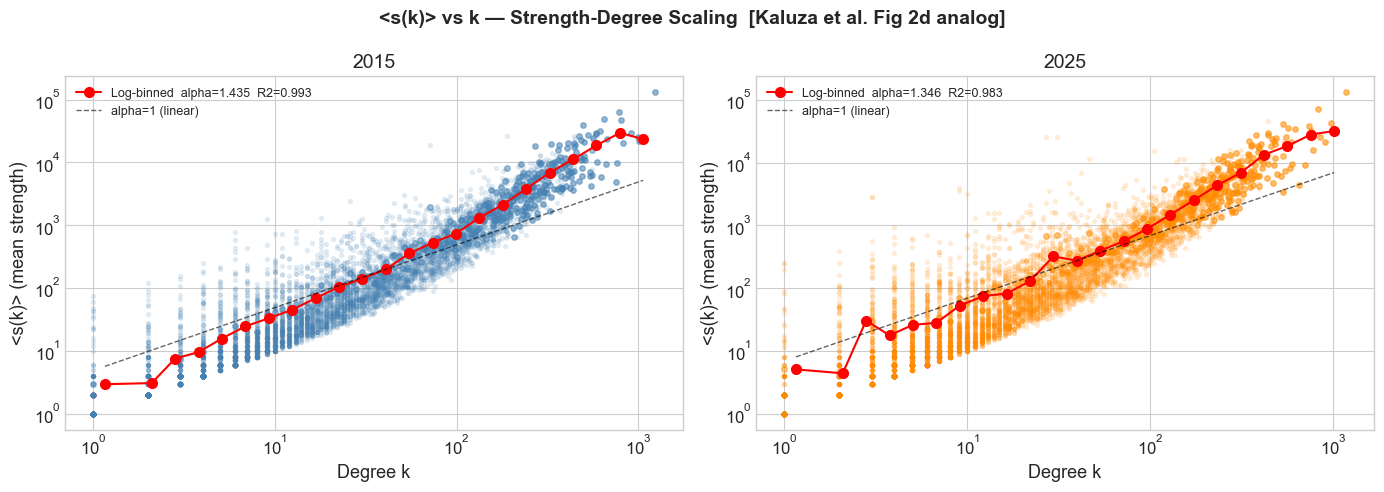


Paper 2007: s(k) ~ k^1.36  (superlinear scaling)
2015: alpha = 1.435  (R^2 = 0.993)
2025: alpha = 1.346  (R^2 = 0.983)

alpha > 1 => superlinear: high-degree ports carry disproportionately more traffic.
alpha = 1 => linear: each link contributes equal average weight.


In [17]:
def strength_degree_scaling(Gu, year, color):
    """Compute and plot <s(k)> vs k. Fit s(k) ~ k^alpha."""
    deg      = dict(Gu.degree())
    strength = dict(Gu.degree(weight='weight'))

    k_vals = np.array([deg[n]      for n in Gu.nodes()])
    s_vals = np.array([strength[n] for n in Gu.nodes()])

    # Bin by degree and take mean strength per bin
    sk_map = defaultdict(list)
    for k, s in zip(k_vals, s_vals):
        if k > 0:
            sk_map[k].append(s)

    k_unique = np.array(sorted(sk_map.keys()))
    s_mean   = np.array([np.mean(sk_map[k]) for k in k_unique])

    # Log-bin
    if k_unique.max() > k_unique.min():
        bins = np.logspace(np.log10(k_unique.min()),
                           np.log10(k_unique.max()), 25)
        k_bin, s_bin = [], []
        for i in range(len(bins) - 1):
            mask = (k_unique >= bins[i]) & (k_unique < bins[i + 1])
            if mask.sum() > 0:
                k_bin.append(np.sqrt(bins[i] * bins[i + 1]))
                s_bin.append(np.mean(s_mean[mask]))
        k_bin = np.array(k_bin)
        s_bin = np.array(s_bin)
    else:
        k_bin, s_bin = k_unique, s_mean

    # Fit alpha in log-log
    valid = (k_bin > 0) & (s_bin > 0)
    if valid.sum() >= 3:
        alpha, intercept, r, p, _ = stats.linregress(
            np.log10(k_bin[valid]), np.log10(s_bin[valid]))
        r2 = r ** 2
    else:
        alpha, intercept, r2 = np.nan, np.nan, np.nan

    return {
        'alpha': alpha, 'r2': r2,
        'k_all': k_vals, 's_all': s_vals,
        'k_bin': k_bin,  's_bin': s_bin,
        'k_unique': k_unique, 's_mean': s_mean
    }


sc_2015 = strength_degree_scaling(Gu_2015, '2015', 'steelblue')
sc_2025 = strength_degree_scaling(Gu_2025, '2025', 'darkorange')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('<s(k)> vs k — Strength-Degree Scaling  [Kaluza et al. Fig 2d analog]',
             fontsize=14, fontweight='bold')

for ax, sc, year, color in [
    (axes[0], sc_2015, '2015', 'steelblue'),
    (axes[1], sc_2025, '2025', 'darkorange')
]:
    ax.scatter(sc['k_all'], sc['s_all'], alpha=0.12, s=8, color=color)
    ax.loglog(sc['k_unique'], sc['s_mean'], 'o', ms=4, alpha=0.5, color=color)
    ax.loglog(sc['k_bin'], sc['s_bin'], 'o-', ms=7, color='red', lw=1.5,
              label=f'Log-binned  alpha={sc["alpha"]:.3f}  R2={sc["r2"]:.3f}')

    # Linear reference (alpha=1)
    if len(sc['k_bin']) > 0:
        k_ref = np.logspace(np.log10(sc['k_bin'].min()),
                            np.log10(sc['k_bin'].max()), 100)
        mid = len(sc['k_bin']) // 2
        scale_lin = sc['s_bin'][mid] / sc['k_bin'][mid]  # linear scale
        ax.loglog(k_ref, scale_lin * k_ref, 'k--', lw=1, alpha=0.6, label='alpha=1 (linear)')

    ax.set_xlabel('Degree k')
    ax.set_ylabel('<s(k)> (mean strength)')
    ax.set_title(f'{year}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR + '02_strength_degree_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nPaper 2007: s(k) ~ k^1.36  (superlinear scaling)')
print(f'2015: alpha = {sc_2015["alpha"]:.3f}  (R^2 = {sc_2015["r2"]:.3f})')
print(f'2025: alpha = {sc_2025["alpha"]:.3f}  (R^2 = {sc_2025["r2"]:.3f})')
print()
print('alpha > 1 => superlinear: high-degree ports carry disproportionately more traffic.')
print('alpha = 1 => linear: each link contributes equal average weight.')


## 5. Weighted Clustering Coefficient

The weighted clustering coefficient (Barrat et al. 2004) gives more weight to triangles formed by high-traffic links.

Comparing C (unweighted) vs C_w (weighted) tells us whether well-used links form tighter triangles.


  2015: C (unweighted) = 0.5223,  C (weighted) = 0.0002
  2025: C (unweighted) = 0.4884,  C (weighted) = 0.0001


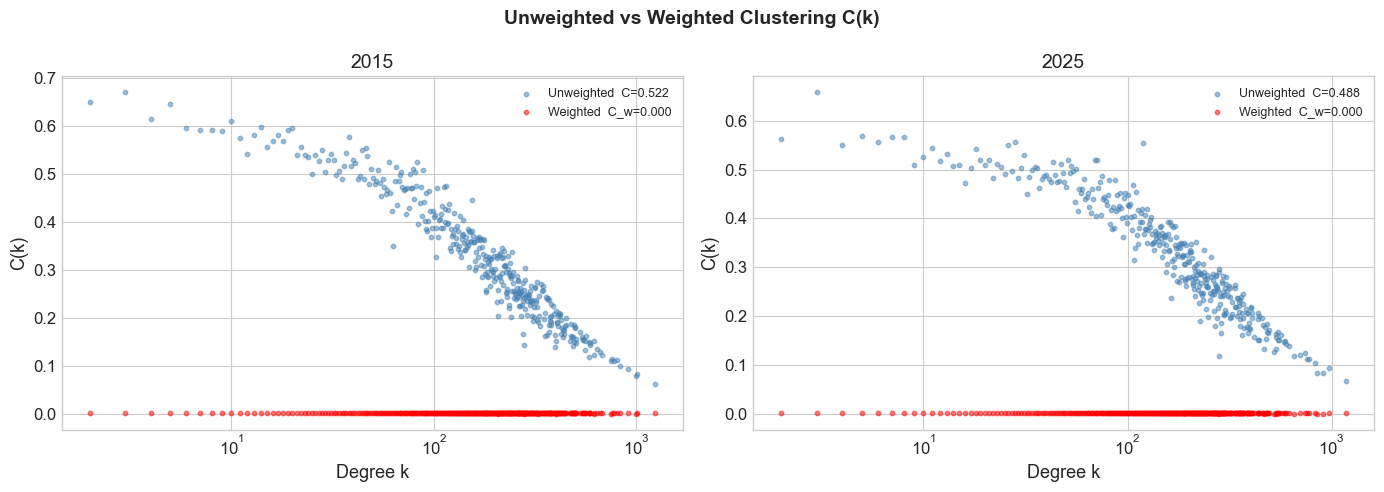


If C_w > C_unw: high-weight links form more triangles than average.
If C_w < C_unw: traffic is concentrated on non-triangular (hub-and-spoke) routes.


In [18]:
def weighted_clustering_analysis(Gu_w, Gu_uw, year):
    """
    Compare unweighted vs weighted clustering.
    Gu_w  = weighted undirected graph
    Gu_uw = unweighted undirected graph (same topology)
    """
    C_unw = nx.average_clustering(Gu_uw)
    C_w   = nx.average_clustering(Gu_w, weight='weight')

    clust_unw = nx.clustering(Gu_uw)
    clust_w   = nx.clustering(Gu_w, weight='weight')
    deg       = dict(Gu_uw.degree())

    # Group by degree
    ck_unw = defaultdict(list)
    ck_w   = defaultdict(list)
    for n in Gu_uw.nodes():
        k = deg[n]
        if k > 1:
            ck_unw[k].append(clust_unw[n])
            ck_w[k].append(clust_w[n])

    k_sorted = np.array(sorted(ck_unw.keys()))
    c_sorted_unw = np.array([np.mean(ck_unw[k]) for k in k_sorted])
    c_sorted_w   = np.array([np.mean(ck_w[k])   for k in k_sorted])

    print(f'  {year}: C (unweighted) = {C_unw:.4f},  C (weighted) = {C_w:.4f}')

    return {
        'C_unw': C_unw, 'C_w': C_w,
        'k_sorted': k_sorted,
        'c_sorted_unw': c_sorted_unw,
        'c_sorted_w': c_sorted_w
    }


# Build unweighted versions for comparison
Gu_uw_2015 = nx.Graph()
Gu_uw_2015.add_edges_from(zip(df_2015['source'], df_2015['target']))

Gu_uw_2025 = nx.Graph()
Gu_uw_2025.add_edges_from(zip(df_2025['source'], df_2025['target']))

wc_2015 = weighted_clustering_analysis(Gu_2015, Gu_uw_2015, '2015')
wc_2025 = weighted_clustering_analysis(Gu_2025, Gu_uw_2025, '2025')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Unweighted vs Weighted Clustering C(k)', fontsize=14, fontweight='bold')

for ax, wc, year in [(axes[0], wc_2015, '2015'), (axes[1], wc_2025, '2025')]:
    ax.scatter(wc['k_sorted'], wc['c_sorted_unw'], alpha=0.5, s=10,
               color='steelblue', label=f'Unweighted  C={wc["C_unw"]:.3f}')
    ax.scatter(wc['k_sorted'], wc['c_sorted_w'], alpha=0.5, s=10,
               color='red', label=f'Weighted  C_w={wc["C_w"]:.3f}')
    ax.set_xscale('log')
    ax.set_xlabel('Degree k')
    ax.set_ylabel('C(k)')
    ax.set_title(f'{year}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR + '02_weighted_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nIf C_w > C_unw: high-weight links form more triangles than average.')
print(f'If C_w < C_unw: traffic is concentrated on non-triangular (hub-and-spoke) routes.')


## 6. Weighted Assortativity and KNN



  2015: assortativity (undirected) r = -0.0694
         assortativity (in-in)  = -0.0542
         assortativity (out-out) = -0.0557

  2025: assortativity (undirected) r = -0.0080
         assortativity (in-in)  = 0.0024
         assortativity (out-out) = -0.0053


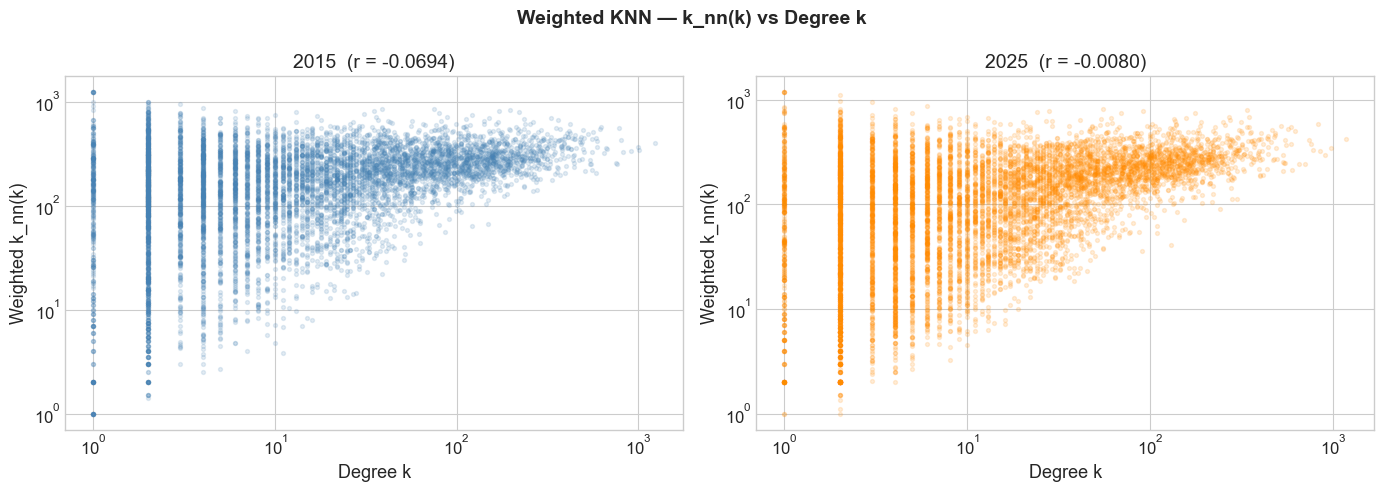

In [19]:
def weighted_assortativity(Gd_w, Gu_w, year):
    try:
        r_in_in  = nx.degree_assortativity_coefficient(Gd_w, x='in',  y='in')
        r_out_out= nx.degree_assortativity_coefficient(Gd_w, x='out', y='out')
    except Exception:
        r_in_in, r_out_out = np.nan, np.nan

    r_uw = nx.degree_assortativity_coefficient(Gu_w)

    # Weighted KNN
    knn_w = nx.average_neighbor_degree(Gu_w, weight='weight')
    knn_u = nx.average_neighbor_degree(Gu_w)
    deg   = dict(Gu_w.degree())

    k_all    = np.array([deg[n]    for n in Gu_w.nodes()])
    knn_vals = np.array([knn_w[n]  for n in Gu_w.nodes()])

    print(f'\n  {year}: assortativity (undirected) r = {r_uw:.4f}')
    print(f'         assortativity (in-in)  = {r_in_in:.4f}')
    print(f'         assortativity (out-out) = {r_out_out:.4f}')

    return {
        'r_uw': r_uw, 'r_in_in': r_in_in, 'r_out_out': r_out_out,
        'k_all': k_all, 'knn_vals': knn_vals
    }


wa_2015 = weighted_assortativity(Gd_2015, Gu_2015, '2015')
wa_2025 = weighted_assortativity(Gd_2025, Gu_2025, '2025')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Weighted KNN — k_nn(k) vs Degree k', fontsize=14, fontweight='bold')

for ax, wa, year, color in [
    (axes[0], wa_2015, '2015', 'steelblue'),
    (axes[1], wa_2025, '2025', 'darkorange')
]:
    ax.scatter(wa['k_all'], wa['knn_vals'], alpha=0.15, s=8, color=color)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree k')
    ax.set_ylabel('Weighted k_nn(k)')
    ax.set_title(f'{year}  (r = {wa["r_uw"]:.4f})')

plt.tight_layout()
plt.savefig(FIG_DIR + '02_weighted_knn.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Top Ports by Strength (Traffic Load)

Node strength = total number of voyages entering or leaving a port.  
This is the weighted equivalent of degree centrality.



Top 25 ports by strength (total voyages) — 2015
                   port  strength  in_voyages  out_voyages  degree  voyages_per_link
           chn-shanghai    129906       65067        64839    1233        105.357664
             chn-ningbo     64368       32192        32176     779         82.629012
           jpn-yokohama     48700       24358        24342     643         75.738725
           chn-hongkong     47815       23938        23877     804         59.471393
               jpn-kobe     39560       19780        19780     497         79.597586
         chn-caofeidian     31968       16041        15927     615         51.980488
          mys-pengerang     29401       14892        14509     910         32.308791
              kor-busan     29040       14520        14520     588         49.387755
           tur-istanbul     28559       14300        14259     581         49.154905
           chn-shenzhen     27246       13632        13614     527         51.700190
             chn

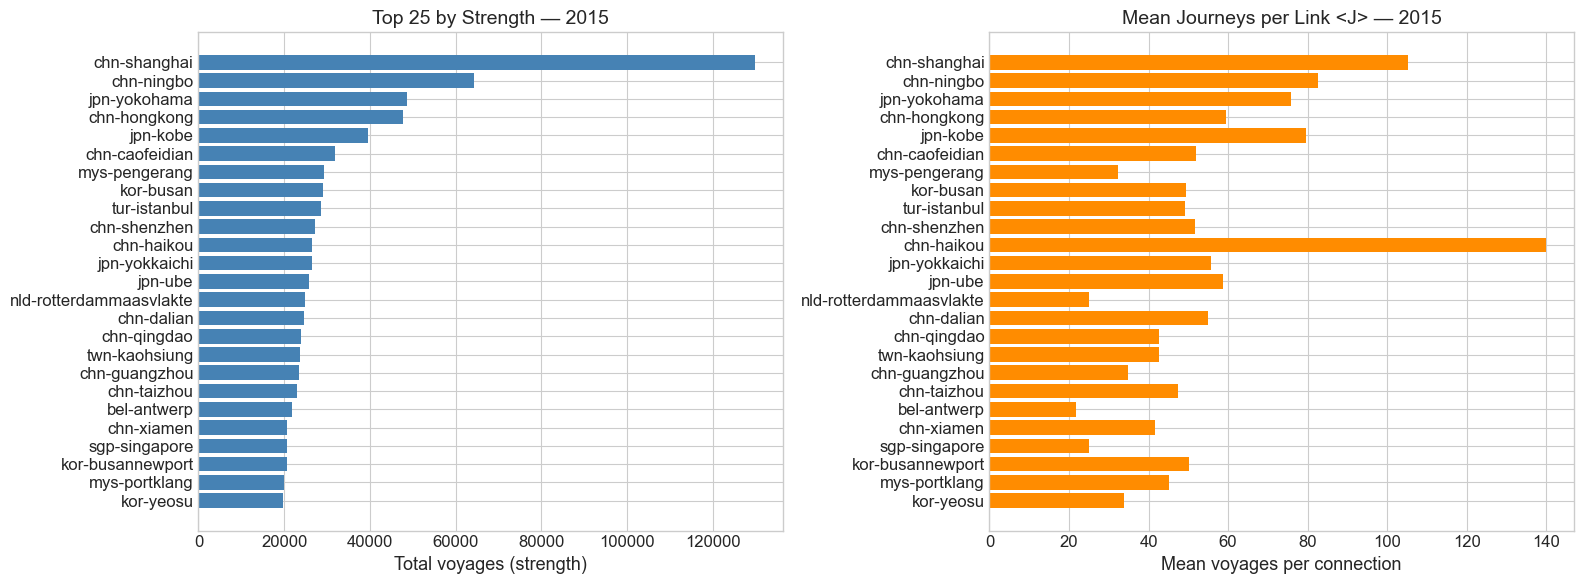


Top 25 ports by strength (total voyages) — 2025
                   port  strength  in_voyages  out_voyages  degree  voyages_per_link
           chn-shanghai    132175       66195        65980    1171        112.873612
             chn-ningbo     71373       35694        35679     829         86.095296
               jpn-kobe     46113       23057        23056     437        105.521739
       mys-telokramunia     42848       21706        21142     974         43.991786
           jpn-yokohama     42040       21031        21009     532         79.022556
           chn-hongkong     37871       18939        18932     737         51.385346
         chn-caofeidian     36239       18088        18151     564         64.253546
           chn-shenzhen     34810       17429        17381     618         56.326861
          chn-guangzhou     31752       15877        15875     756         42.000000
          jpn-yokkaichi     27864       13938        13926     439         63.471526
                

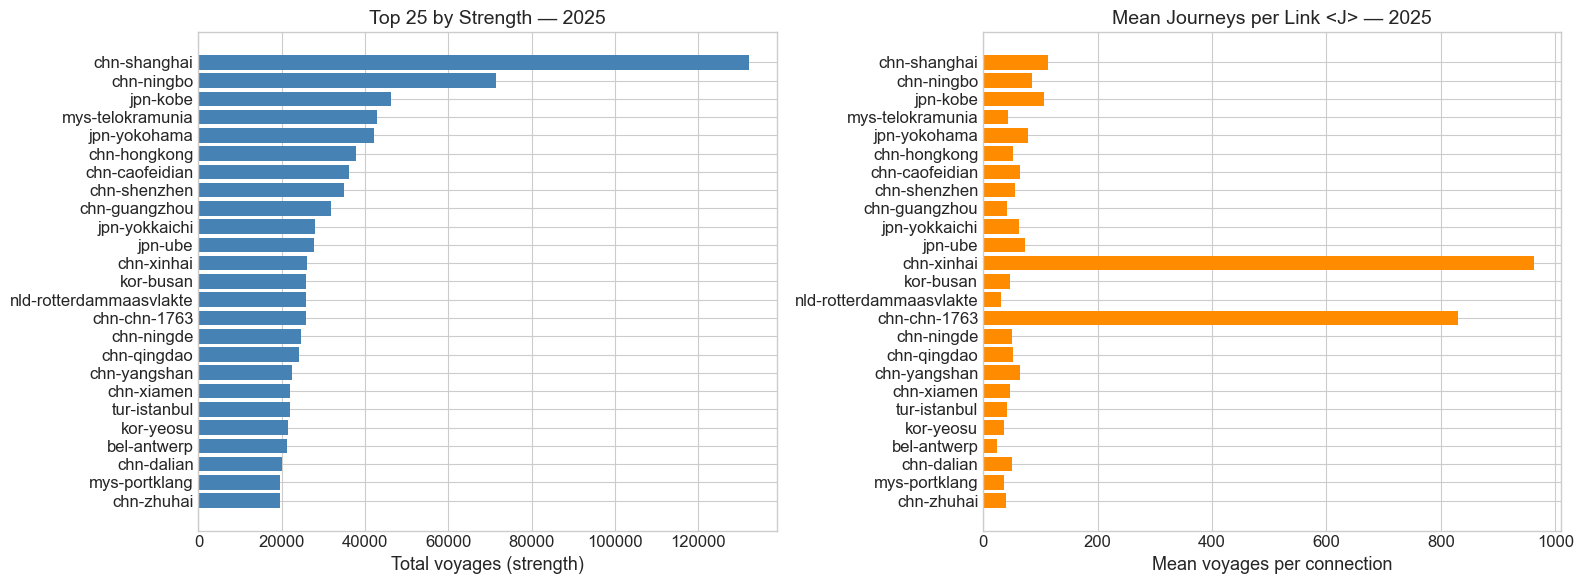

In [20]:
TOP_N = 25

def top_ports_strength(Gd, Gu, year, top_n=TOP_N):
    strength = dict(Gu.degree(weight='weight'))
    in_str   = {n: sum(d['weight'] for _, _, d in Gd.in_edges(n, data=True))
                for n in Gd.nodes()}
    out_str  = {n: sum(d['weight'] for _, _, d in Gd.out_edges(n, data=True))
                for n in Gd.nodes()}

    top = sorted(strength.items(), key=lambda x: x[1], reverse=True)[:top_n]

    rows = []
    for port, s in top:
        rows.append({
            'port': port,
            'strength': s,
            'in_voyages': in_str.get(port, 0),
            'out_voyages': out_str.get(port, 0),
            'degree': Gu.degree(port)
        })
    df_top = pd.DataFrame(rows)
    df_top['voyages_per_link'] = df_top['strength'] / df_top['degree']

    print(f'\nTop {top_n} ports by strength (total voyages) — {year}')
    print(df_top.to_string(index=False))

    fig, axes2 = plt.subplots(1, 2, figsize=(16, 6))
    # Strength
    axes2[0].barh(df_top['port'][::-1], df_top['strength'][::-1],
                  color='steelblue', edgecolor='none')
    axes2[0].set_xlabel('Total voyages (strength)')
    axes2[0].set_title(f'Top {top_n} by Strength — {year}')
    # Voyages per link
    axes2[1].barh(df_top['port'][::-1], df_top['voyages_per_link'][::-1],
                  color='darkorange', edgecolor='none')
    axes2[1].set_xlabel('Mean voyages per connection')
    axes2[1].set_title(f'Mean Journeys per Link <J> — {year}')

    plt.tight_layout()
    plt.savefig(FIG_DIR + f'02_top_ports_strength_{year}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return df_top


top_2015 = top_ports_strength(Gd_2015, Gu_2015, '2015')
top_2025 = top_ports_strength(Gd_2025, Gu_2025, '2025')


## 8. Most Active Routes (Edges)



Top 20 routes by weight — 2015
                                                 route  weight
                          chn-ningbo  ->  chn-shanghai   10269
                             chn-haian  ->  chn-haikou    9258
                             chn-haikou  ->  chn-haian    9242
                      deu-strande  ->  deu-brunsbuttel    5631
                          chn-shanghai  ->  chn-ningbo    5328
                       jpn-yokohama  ->  jpn-yokkaichi    3758
                            chn-yantai  ->  chn-dalian    3681
                            chn-dalian  ->  chn-yantai    3572
                      chn-shanghai  ->  chn-caofeidian    3347
          pan-manzanillo  ->  pan-panamacanalanchorage    3159
                        chn-hongkong  ->  chn-shenzhen    3117
                        chn-yangshan  ->  chn-shanghai    3097
                        chn-majishan  ->  chn-shanghai    2972
                                 jpn-kobe  ->  jpn-ube    2890
pan-panamaanchoragepaci

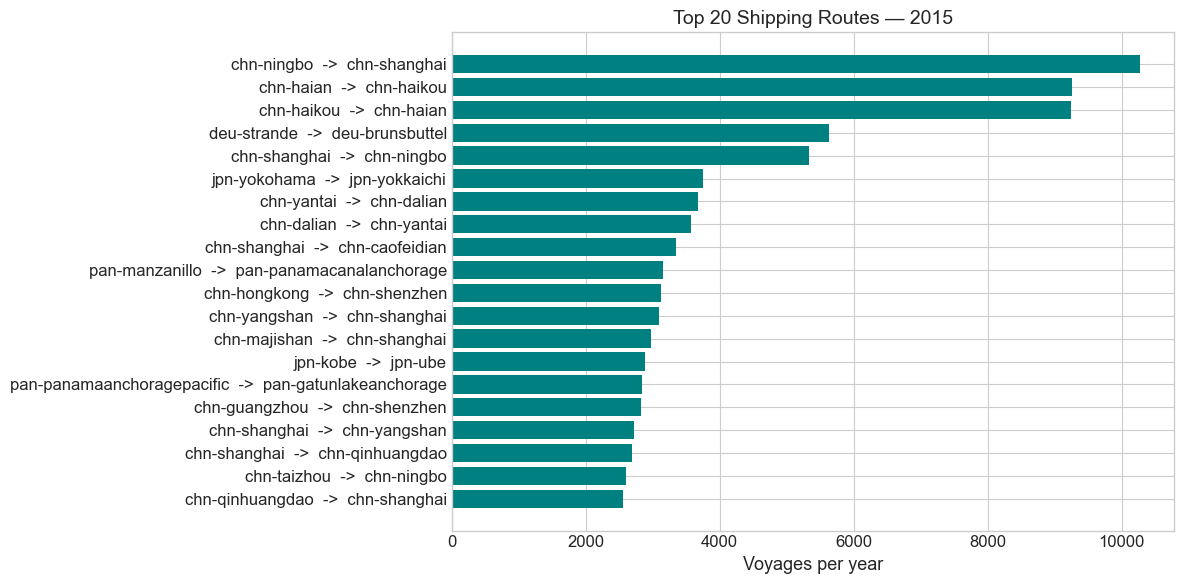


Top 20 routes by weight — 2025
                           route  weight
    chn-chn-1763  ->  chn-xinhai   12779
    chn-xinhai  ->  chn-chn-1763   12742
    chn-ningbo  ->  chn-shanghai   11225
    chn-shanghai  ->  chn-ningbo   10722
       chn-haian  ->  chn-haikou    5621
       chn-haikou  ->  chn-haian    5616
  chn-yangshan  ->  chn-shanghai    4769
 chn-guangzhou  ->  chn-shenzhen    4728
chn-shanghai  ->  chn-caofeidian    4040
deu-strande  ->  deu-brunsbuttel    3950
   chn-taizhou  ->  chn-chn-2373    3301
     irn-lengeh  ->  are-sharjah    3240
     are-sharjah  ->  irn-lengeh    3190
chn-caofeidian  ->  chn-shanghai    3156
 jpn-yokohama  ->  jpn-yokkaichi    3116
  chn-hongkong  ->  chn-shenzhen    3085
    deu-otterndorf  ->  deu-kiel    3064
    chn-shenzhen  ->  chn-zhuhai    3038
  chn-shanghai  ->  chn-yangshan    2864
           jpn-kobe  ->  jpn-ube    2851


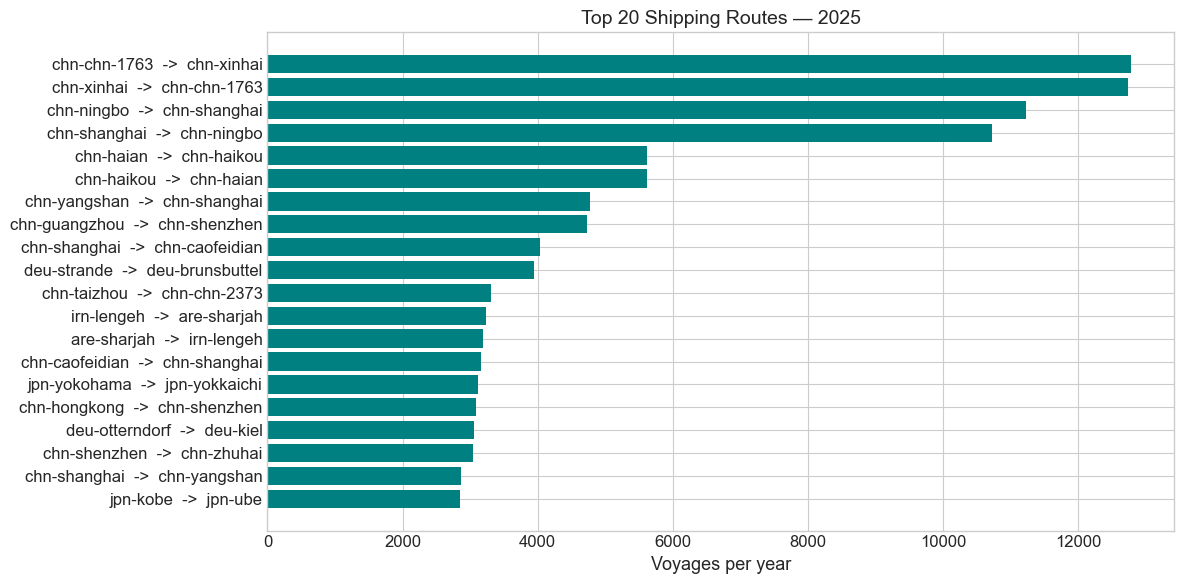

In [21]:
TOP_ROUTES = 20

def top_routes(df, year, top_n=TOP_ROUTES):
    top = df.nlargest(top_n, 'weight').copy()
    top['route'] = top['source'] + '  ->  ' + top['target']
    print(f'\nTop {top_n} routes by weight — {year}')
    print(top[['route', 'weight']].to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(top['route'][::-1], top['weight'][::-1],
            color='teal', edgecolor='none')
    ax.set_xlabel('Voyages per year')
    ax.set_title(f'Top {top_n} Shipping Routes — {year}')
    plt.tight_layout()
    plt.savefig(FIG_DIR + f'02_top_routes_{year}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return top


routes_2015 = top_routes(df_2015, '2015')
routes_2025 = top_routes(df_2025, '2025')


## 9. Summary Table — Weighted Metrics


In [22]:
rows = [
    ('Year',                                 '2015',                               '2025',                               '2007 (paper)'),
    ('Directed edges',                        f'{Gd_2015.number_of_edges():,}',     f'{Gd_2025.number_of_edges():,}',     '—'),
    ('Undirected edges',                      f'{Gu_2015.number_of_edges():,}',     f'{Gu_2025.number_of_edges():,}',     '—'),
    ('Total voyages (sum of all weights)',     f'{ws_2015["weights_d"].sum():,}',    f'{ws_2025["weights_d"].sum():,}',    '—'),
    ('Mean journeys per link <J>',            f'{ws_2015["mean_J"]:.2f}',           f'{ws_2025["mean_J"]:.2f}',           str(PAPER_2007["journeys_per_link"])),
    ('Max link weight',                       f'{ws_2015["max_w"]:,}',              f'{ws_2025["max_w"]:,}',              '—'),
    ('Mean node strength <s>',                f'{ws_2015["mean_s"]:.1f}',           f'{ws_2025["mean_s"]:.1f}',           '—'),
    ('Link weight MLE exponent mu',           f'{mu_w["2015"]:.3f}',               f'{mu_w["2025"]:.3f}',               f'~{PAPER_2007["weight_exponent_mu"]}'),
    ('Strength MLE exponent eta',             f'{eta_s["2015"]:.3f}',              f'{eta_s["2025"]:.3f}',              str(PAPER_2007["strength_exponent_eta"])),
    ('Strength-degree scaling alpha',         f'{sc_2015["alpha"]:.3f}',           f'{sc_2025["alpha"]:.3f}',           str(PAPER_2007["superlinear_alpha"])),
    ('Strength-degree R^2',                   f'{sc_2015["r2"]:.3f}',              f'{sc_2025["r2"]:.3f}',              '—'),
    ('Weighted clustering C_w',               f'{wc_2015["C_w"]:.4f}',             f'{wc_2025["C_w"]:.4f}',             '—'),
    ('Unweighted clustering C',               f'{wc_2015["C_unw"]:.4f}',           f'{wc_2025["C_unw"]:.4f}',           str(PAPER_2007["clustering"])),
    ('Assortativity r (undirected)',          f'{wa_2015["r_uw"]:.4f}',            f'{wa_2025["r_uw"]:.4f}',            '—'),
    ('Assortativity r (in-in, directed)',     f'{wa_2015["r_in_in"]:.4f}',         f'{wa_2025["r_in_in"]:.4f}',         '—'),
    ('Assortativity r (out-out, directed)',   f'{wa_2015["r_out_out"]:.4f}',       f'{wa_2025["r_out_out"]:.4f}',       '—'),
]

df_sum = pd.DataFrame(rows, columns=['Metric', '2015', '2025', 'Paper 2007'])

print()
print('=' * 85)
print('  GCSN WEIGHTED NETWORK — SUMMARY TABLE')
print('  Reference: Kaluza et al. (2010), J. R. Soc. Interface, doi:10.1098/rsif.2009.0495')
print('=' * 85)
print(df_sum.to_string(index=False))
print('=' * 85)

df_sum.to_csv('../Figures/02_summary_weighted.csv', index=False)
print('\nSummary saved to ../Figures/02_summary_weighted.csv')



  GCSN WEIGHTED NETWORK — SUMMARY TABLE
  Reference: Kaluza et al. (2010), J. R. Soc. Interface, doi:10.1098/rsif.2009.0495
                             Metric      2015      2025   Paper 2007
                               Year      2015      2025 2007 (paper)
                     Directed edges   188,545   182,300            —
                   Undirected edges   145,745   139,499            —
 Total voyages (sum of all weights) 1,791,795 1,965,325            —
         Mean journeys per link <J>      9.50     10.78         10.4
                    Max link weight    10,269    12,779            —
             Mean node strength <s>     504.9     509.3            —
        Link weight MLE exponent mu     1.643     1.617        ~1.42
          Strength MLE exponent eta     1.236     1.233         1.02
      Strength-degree scaling alpha     1.435     1.346         1.36
                Strength-degree R^2     0.993     0.983            —
            Weighted clustering C_w    0.0002  

---
## 10. Kaluza et al. Table 1 — Full Replication

Table 1 of Kaluza et al. (2010) reports structural metrics for the combined GCSN and for four individual cargo-type sub-networks (container ships, bulk dry carriers, oil tankers, general cargo).

We reproduce the same metric set for our **combined networks (2015 and 2025)** and place them alongside all paper baselines so direct comparison is possible.

| Metric | Description |
|--------|-------------|
| N | number of port nodes |
| E | number of undirected edges |
| `<k>` | mean degree |
| `<J>` | mean journeys per link (= mean edge weight) |
| C | unweighted clustering coefficient |
| C_w | weighted clustering coefficient (Barrat 2004) |
| mu | MLE power-law exponent of P(w) ~ w^{-mu} |
| eta | MLE power-law exponent of P(s) ~ s^{-eta} |
| alpha | strength-degree scaling exponent s(k) ~ k^{alpha} |
| `<L>` | mean shortest path (sampled, 500 nodes from LCC) |

In [25]:
def avg_shortest_path_sampled(Gu, n_samples=500, seed=42):
    """Estimate <L> by averaging BFS distances from a random node sample in the LCC."""
    rng = np.random.default_rng(seed)
    lcc_nodes = max(nx.connected_components(Gu), key=len)
    G_lcc = Gu.subgraph(lcc_nodes)
    nodes = list(G_lcc.nodes())
    sample = rng.choice(nodes, size=min(n_samples, len(nodes)), replace=False)
    total, count = 0.0, 0
    for src in sample:
        lengths = nx.single_source_shortest_path_length(G_lcc, src)
        total += sum(lengths.values())
        count += len(lengths) - 1        # exclude self
    return total / count if count > 0 else np.nan


def full_table1_metrics(label, year, Gd, Gu, weights_d, strengths,
                        mu_val, eta_val, sc_result, wc_result,
                        compute_L=True, n_samples=500):
    """Assemble one Table-1 row from already-computed intermediate results."""
    N  = Gu.number_of_nodes()
    E  = Gu.number_of_edges()
    k_mean = 2 * E / N if N > 0 else 0
    J_mean = float(weights_d.mean()) if len(weights_d) > 0 else np.nan

    L = avg_shortest_path_sampled(Gu, n_samples=n_samples) if compute_L else np.nan

    return {
        'Network'   : label,
        'Year'      : year,
        'N'         : N,
        'E'         : E,
        '<k>'       : round(k_mean,        2),
        '<J>'       : round(J_mean,        2),
        'C'         : round(wc_result['C_unw'], 4),
        'C_w'       : round(wc_result['C_w'],   4),
        'mu'        : round(mu_val,         3),
        'eta'       : round(eta_val,        3),
        'alpha'     : round(sc_result['alpha'], 3) if not np.isnan(sc_result['alpha']) else np.nan,
        '<L>'       : round(L, 3) if not np.isnan(L) else '—',
    }


print('Computing Table 1 metrics for 2015 and 2025 combined networks …')
print('(shortest-path sampling may take ~30–60 s per network)')

row_2015 = full_table1_metrics(
    'GCSN combined', '2015',
    Gd_2015, Gu_2015,
    ws_2015['weights_d'], ws_2015['strengths'],
    mu_w['2015'], eta_s['2015'], sc_2015, wc_2015,
    compute_L=True, n_samples=500,
)

row_2025 = full_table1_metrics(
    'GCSN combined', '2025',
    Gd_2025, Gu_2025,
    ws_2025['weights_d'], ws_2025['strengths'],
    mu_w['2025'], eta_s['2025'], sc_2025, wc_2025,
    compute_L=True, n_samples=500,
)

# ── Paper (Kaluza 2010) reference rows ───────────────────────────────
PAPER_ROWS = [
    {'Network': 'combined (paper)',      'Year': '2007', 'N':  951, 'E': '—',
     '<k>': 44.61, '<J>': 10.4, 'C': 0.49, 'C_w': '—',
     'mu': '—',  'eta': '—',  'alpha': 1.36, '<L>': 2.50},
]

df_t1 = pd.DataFrame([row_2015, row_2025] + PAPER_ROWS)

print()
print('=' * 110)
print('  TABLE 1 — GCSN Structural Metrics  |  Kaluza et al. (2010) Replication')
print('  Reference: Kaluza, Kölzsch, Gastner & Blasius (2010), J. R. Soc. Interface 7, 1093–1103')
print('=' * 110)
print(df_t1.to_string(index=False))
print('=' * 110)
print()
print('Notes:')
print('  C_w  = weighted clustering (Barrat et al. 2004) — not reported in the paper')
print('  <L>  = mean shortest path estimated from 500 randomly sampled nodes in the LCC')
print('  mu / eta / alpha fitted via MLE on the continuous power-law approximation')
print()
print(f'  2015 combined: N={row_2015["N"]:,}, <k>={row_2015["<k>"]}, C={row_2015["C"]}, alpha={row_2015["alpha"]}')
print(f'  2025 combined: N={row_2025["N"]:,}, <k>={row_2025["<k>"]}, C={row_2025["C"]}, alpha={row_2025["alpha"]}')

df_t1.to_csv('../Figures/02_table1_replication.csv', index=False)
print('\nSaved → ../Figures/02_table1_replication.csv')


Computing Table 1 metrics for 2015 and 2025 combined networks …
(shortest-path sampling may take ~30–60 s per network)

  TABLE 1 — GCSN Structural Metrics  |  Kaluza et al. (2010) Replication
  Reference: Kaluza, Kölzsch, Gastner & Blasius (2010), J. R. Soc. Interface 7, 1093–1103
         Network Year    N      E   <k>   <J>      C     C_w     mu    eta  alpha   <L>
   GCSN combined 2015 7097 145745 41.07  9.50 0.5223  0.0002  1.643  1.236  1.435 3.299
   GCSN combined 2025 7717 139499 36.15 10.78 0.4884  0.0001  1.617  1.233  1.346 3.563
combined (paper) 2007  951      — 44.61 10.40 0.4900       —      —      —  1.360 2.500

Notes:
  C_w  = weighted clustering (Barrat et al. 2004) — not reported in the paper
  <L>  = mean shortest path estimated from 500 randomly sampled nodes in the LCC
  mu / eta / alpha fitted via MLE on the continuous power-law approximation

  2015 combined: N=7,097, <k>=41.07, C=0.5223, alpha=1.435
  2025 combined: N=7,717, <k>=36.15, C=0.4884, alpha=1.346

Sa

---
## 11. Kaluza et al. Fig. 2 — Composite Replication

Figure 2 of Kaluza et al. shows three panels for the combined GCSN:
- **2b** P(w) ~ w^{-mu} — link weight distribution
- **2c** P(s) ~ s^{-eta} — node strength distribution
- **2d** \<s(k)\> ~ k^{alpha} — strength–degree scaling

We reproduce all three panels side-by-side for **2015** (blue) and **2025** (orange), with fitted power-law lines, in the same layout as the original figure.

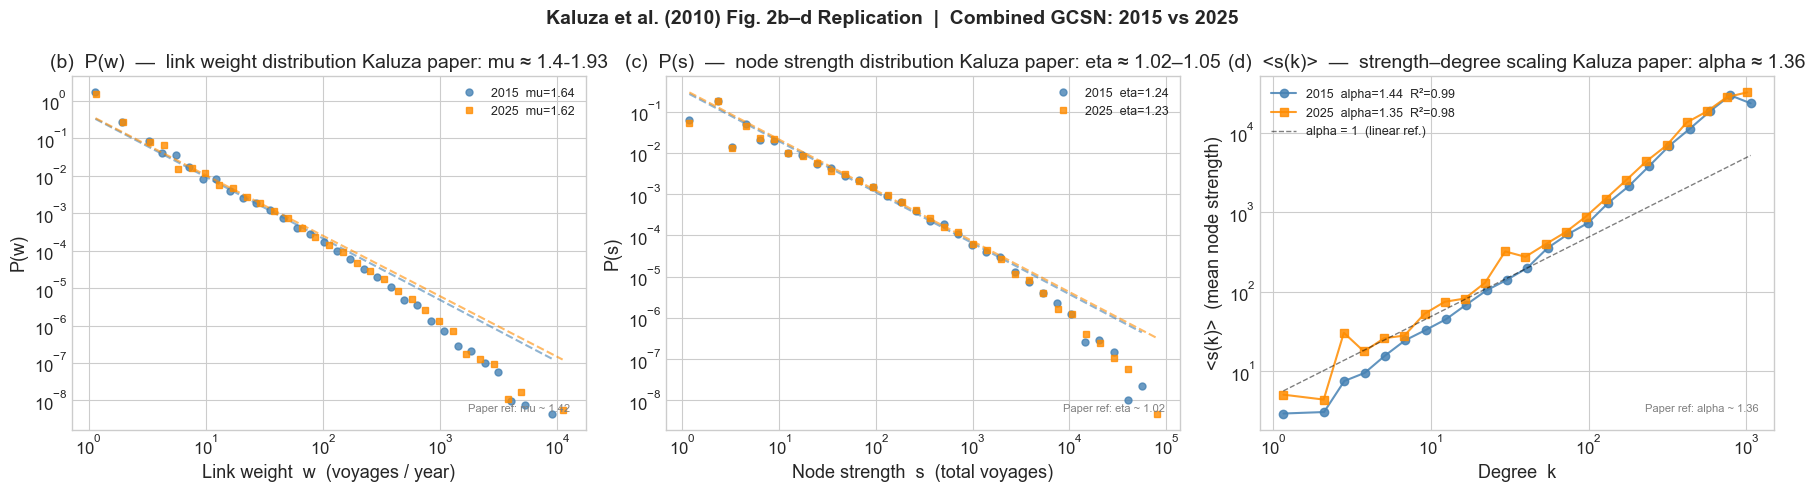

Composite Fig. 2b–d saved → ../Figures/02_fig2_composite_replication.png

Exponent comparison  (paper combined-network baselines in parentheses):
  mu   2015=1.643  2025=1.617   (paper: ~1.42 container, 1.93 bulk, 1.01 tanker)
  eta  2015=1.236  2025=1.233   (paper: ~1.02–1.05 across all types)
  alpha 2015=1.435 2025=1.346   (paper: 1.36 combined, >1 ⟹ superlinear)


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Kaluza et al. (2010) Fig. 2b–d Replication  |  Combined GCSN: 2015 vs 2025',
    fontsize=14, fontweight='bold')

YEAR_STYLE = {
    '2015': ('steelblue',  'o', '2015'),
    '2025': ('darkorange', 's', '2025'),
}

# ── Panel 2b : P(w) ──────────────────────────────────────────────────
ax_pw = axes[0]
for year, (color, marker, label) in YEAR_STYLE.items():
    w = ws_2015['weights_d'] if year == '2015' else ws_2025['weights_d']
    xw, pw_ = log_binning(w)
    mu = mu_w[year]
    if len(xw) > 1:
        ax_pw.loglog(xw, pw_, marker, ms=5, alpha=0.8, color=color,
                     label=f'{label}  mu={mu:.2f}')
        mid = max(1, len(xw) // 3)
        scale = pw_[mid] * xw[mid] ** mu
        x_fit = np.logspace(np.log10(xw.min()), np.log10(xw.max()), 200)
        ax_pw.loglog(x_fit, scale * x_fit**(-mu), '--', lw=1.5, color=color, alpha=0.6)

ax_pw.set_xlabel('Link weight  w  (voyages / year)')
ax_pw.set_ylabel('P(w)')
ax_pw.set_title('(b)  P(w)  —  link weight distribution Kaluza paper: mu ≈ 1.4-1.93')
ax_pw.legend(fontsize=9)
ax_pw.annotate('Paper ref: mu ~ 1.42', xy=(0.97, 0.05), xycoords='axes fraction',
               ha='right', fontsize=8, color='gray')

# ── Panel 2c : P(s) ──────────────────────────────────────────────────
ax_ps = axes[1]
for year, (color, marker, label) in YEAR_STYLE.items():
    s = ws_2015['strengths'] if year == '2015' else ws_2025['strengths']
    xs, ps_ = log_binning(s)
    eta = eta_s[year]
    if len(xs) > 1:
        ax_ps.loglog(xs, ps_, marker, ms=5, alpha=0.8, color=color,
                     label=f'{label}  eta={eta:.2f}')
        mid = max(1, len(xs) // 3)
        scale = ps_[mid] * xs[mid] ** eta
        x_fit = np.logspace(np.log10(xs.min()), np.log10(xs.max()), 200)
        ax_ps.loglog(x_fit, scale * x_fit**(-eta), '--', lw=1.5, color=color, alpha=0.6)

ax_ps.set_xlabel('Node strength  s  (total voyages)')
ax_ps.set_ylabel('P(s)')
ax_ps.set_title('(c)  P(s)  —  node strength distribution Kaluza paper: eta ≈ 1.02–1.05')
ax_ps.legend(fontsize=9)
ax_ps.annotate('Paper ref: eta ~ 1.02', xy=(0.97, 0.05), xycoords='axes fraction',
               ha='right', fontsize=8, color='gray')

# ── Panel 2d : <s(k)> vs k ───────────────────────────────────────────
ax_sk = axes[2]
for year, (color, marker, label) in YEAR_STYLE.items():
    Gu = Gu_2015 if year == '2015' else Gu_2025
    sc = sc_2015   if year == '2015' else sc_2025
    if len(sc['k_bin']) > 1:
        ax_sk.loglog(sc['k_bin'], sc['s_bin'], marker + '-', ms=6, lw=1.5,
                     color=color, alpha=0.85,
                     label=f'{label}  alpha={sc["alpha"]:.2f}  R²={sc["r2"]:.2f}')

# Linear reference line
k_ref_min = min(sc_2015['k_bin'].min(), sc_2025['k_bin'].min())
k_ref_max = max(sc_2015['k_bin'].max(), sc_2025['k_bin'].max())
k_ref = np.logspace(np.log10(k_ref_min), np.log10(k_ref_max), 100)
mid = len(sc_2015['k_bin']) // 2
if mid < len(sc_2015['k_bin']):
    lin_scale = sc_2015['s_bin'][mid] / sc_2015['k_bin'][mid]
    ax_sk.loglog(k_ref, lin_scale * k_ref, 'k--', lw=1, alpha=0.5,
                 label='alpha = 1  (linear ref.)')

ax_sk.set_xlabel('Degree  k')
ax_sk.set_ylabel('<s(k)>  (mean node strength)')
ax_sk.set_title('(d)  <s(k)>  —  strength–degree scaling Kaluza paper: alpha ≈ 1.36')
ax_sk.legend(fontsize=9)
ax_sk.annotate('Paper ref: alpha ~ 1.36', xy=(0.97, 0.05), xycoords='axes fraction',
               ha='right', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(FIG_DIR + '02_fig2_composite_replication.png', dpi=150, bbox_inches='tight')
plt.show()

print('Composite Fig. 2b–d saved → ../Figures/02_fig2_composite_replication.png')
print()
print('Exponent comparison  (paper combined-network baselines in parentheses):')
print(f'  mu   2015={mu_w["2015"]:.3f}  2025={mu_w["2025"]:.3f}   (paper: ~1.42 container, 1.93 bulk, 1.01 tanker)')
print(f'  eta  2015={eta_s["2015"]:.3f}  2025={eta_s["2025"]:.3f}   (paper: ~1.02–1.05 across all types)')
print(f'  alpha 2015={sc_2015["alpha"]:.3f} 2025={sc_2025["alpha"]:.3f}   (paper: 1.36 combined, >1 ⟹ superlinear)')
